In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


LOADING THE DATASET

In [16]:
data=pd.read_csv('Customer_Sentiment.csv')

In [17]:
data.head(10)

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no
5,6,other,26-35,central,sports,online,facebook marketplace,5,"amazing experience, highly recommend!",positive,10,yes,no
6,7,male,36-45,south,travel,online,amazon,4,great value for money.,positive,38,yes,no
7,8,other,60+,east,fashion,online,swiggy instamart,5,excellent product! exceeded expectations.,positive,53,no,no
8,9,male,18-25,south,home & kitchen,online,shopclues,3,"product is okay, nothing special.",neutral,7,yes,no
9,10,male,36-45,east,beauty,online,croma,5,great value for money.,positive,56,no,no


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           25000 non-null  int64 
 1   gender                25000 non-null  object
 2   age_group             25000 non-null  object
 3   region                25000 non-null  object
 4   product_category      25000 non-null  object
 5   purchase_channel      25000 non-null  object
 6   platform              25000 non-null  object
 7   customer_rating       25000 non-null  int64 
 8   review_text           25000 non-null  object
 9   sentiment             25000 non-null  object
 10  response_time_hours   25000 non-null  int64 
 11  issue_resolved        25000 non-null  object
 12  complaint_registered  25000 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.5+ MB


In [19]:
data.describe()

,customer_id,customer_rating,response_time_hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,3.002480,36.023480
std,7217.022701,1.404647,20.597941
min,1.000000,1.000000,1.000000
25%,6250.750000,2.000000,18.000000
50%,12500.500000,3.000000,36.000000
75%,18750.250000,4.000000,54.000000
max,25000.000000,5.000000,71.000000


In [20]:
data.isnull().sum()

customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64

In [21]:
data["review_text"].head(10)

0          very disappointed with the quality.
1           fast delivery and great packaging.
2          very disappointed with the quality.
3      product stopped working after few days.
4                   neutral about the quality.
5        amazing experience, highly recommend!
6                       great value for money.
7    excellent product! exceeded expectations.
8            product is okay, nothing special.
9                       great value for money.
Name: review_text, dtype: object

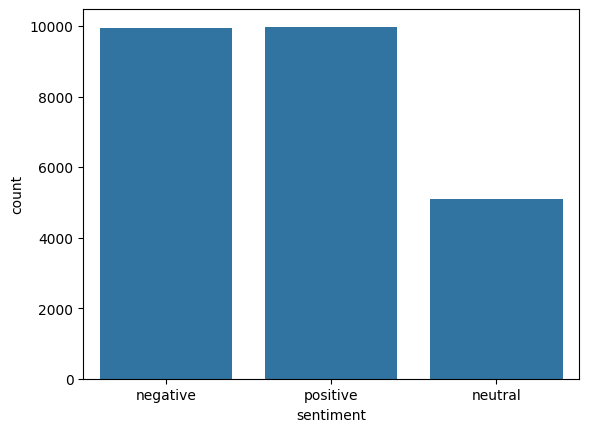

In [22]:
sns.countplot(x='sentiment', data=data)
plt.savefig('images/count_of_sentiment.png')


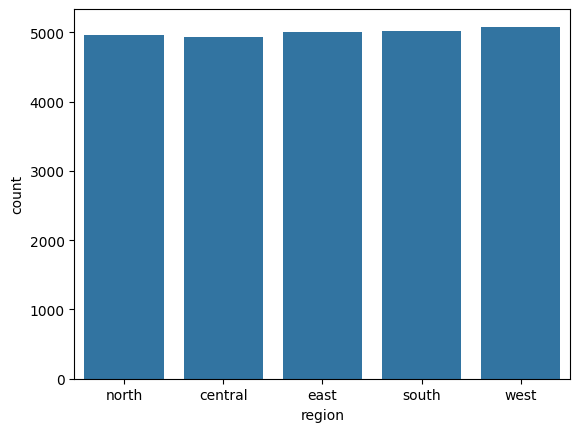

In [23]:
sns.countplot(x='region', data=data)
plt.savefig('images/countplot_of_regions.png')

In [24]:
avg_age_groupby_purchase_channel=data.groupby('age_group')['purchase_channel'].value_counts(normalize=True).unstack()
print(avg_age_groupby_purchase_channel)

purchase_channel  online
age_group               
18-25                1.0
26-35                1.0
36-45                1.0
46-60                1.0
60+                  1.0


In [25]:

print("Regions present:")
print(data['region'].value_counts())
print("Unique regions:", data['region'].unique())

region_by_platform = data.groupby('region')["platform"].value_counts()
print(region_by_platform)

Regions present:
region
west       5081
south      5022
east       5001
north      4963
central    4933
Name: count, dtype: int64
Unique regions: ['north' 'central' 'east' 'south' 'west']
region   platform        
central  zepto               284
         others              277
         nykaa               269
         flipkart            261
         meesho              259
                            ... 
west     reliance digital    245
         jiomart             244
         ajio                238
         paytm mall          234
         amazon              212
Name: count, Length: 100, dtype: int64


### Notes on Regions  
All five regions (`north`, `south`, `east`, `west`, `central`) are present in the dataset.  
Earlier outputs showing only *Central* and *West* were likely from a truncated view or an earlier data slice.  
We normalize the region values to prevent hidden whitespace or casing issues.

region
west       5081
south      5022
east       5001
north      4963
central    4933
Name: count, dtype: int64


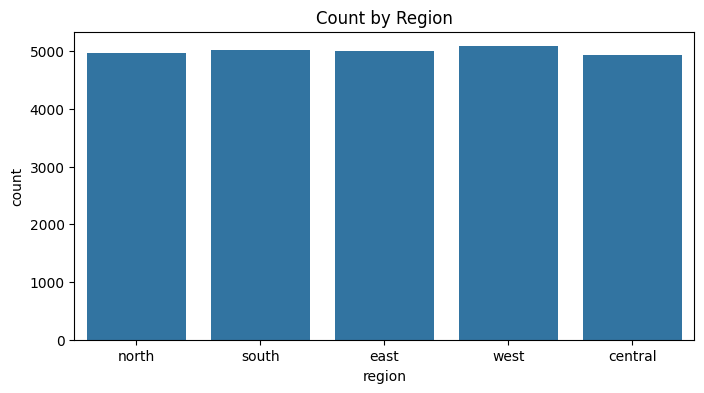

In [26]:

data['region'] = data['region'].str.strip().str.lower()
print(data['region'].value_counts())
plt.figure(figsize=(8,4))
sns.countplot(x='region', data=data, order=['north','south','east','west','central'])
plt.title('Count by Region')
plt.savefig('images/countplot_of_regions_normalized.png')
plt.show()